# Tag Recommendation Experiment (RecSys 2018)

Notebook simple et modulaire pour reproduire une expérience inspirée de l'article **Semantic-based Tag Recommendation in Scientific Bookmarking Systems**.

- Import des données : **1 cellule**
- Une fonction par cellule
- Visualisations déplacées dans `src/visualization.py`
- Dernière cellule : compilation des résultats + visualisations comparatives

In [1]:
import tensorflow as tf
# print(tf.__version__, tf.__file__)
# print("CUDA:", tf.test.is_built_with_cuda())
# print("GPUs:", tf.config.list_physical_devices("GPU"))
# print("GPUs visibles :", tf.config.list_physical_devices("GPU"))
# print("Built with CUDA:", tf.test.is_built_with_cuda())

# # petit test de placement
# with tf.device("/GPU:0"):
#     a = tf.random.normal((1024, 1024))
#     b = tf.matmul(a, a)
# print(b.device)  # doit contenir "GPU:0"
# tf.debugging.set_log_device_placement(True)

tf.config.set_visible_devices([], "GPU")
print(tf.config.list_physical_devices("GPU"))  # should be []

2026-04-17 00:28:14.366590: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-17 00:28:14.373416: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-17 00:28:14.380782: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-17 00:28:14.383272: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-17 00:28:14.389607: I tensorflow/core/platform/cpu_feature_guar

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1776385695.359364   44732 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1776385695.378796   44732 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1776385695.383983   44732 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


In [2]:
# Cellule 1 - Imports (meme stack que l'article)
import sys
from pathlib import Path
import subprocess
import os

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data import (
    load_citeulike_a_dataset, 
    keep_top_k_tags, 
    preprocess_text_nltk, 
    text_length_stats,
    build_sentence_preprocessed
)
from src.experiment import prepare_train_test, run_all_models, run_all_models_hierarchical
from src.visualization import (
    plot_tag_distribution,
    plot_text_length_distributions,
    plot_model_metrics,
    plot_article_vs_current,
)
from src.results_save import save_metrics_enriched

# pd.set_option("display.max_colwidth", 120)

In [3]:
# Cellule 2 - Paramètres globaux
DATA_PATH = Path(PROJECT_ROOT / "data" / "citeulike-a")
if not os.path.exists(DATA_PATH):
    print("target =", DATA_PATH.resolve())
    print("exists =", DATA_PATH.exists())
    if not DATA_PATH.exists():
        DATA_PATH.mkdir(parents=True, exist_ok=True)
        result = subprocess.run(
            ["bash","-c", f"git clone https://github.com/js05212/citeulike-a.git data/citeulike-a"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", "ls -la data"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", f"ls -la {DATA_PATH}"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
GLOVE_PATH = Path(PROJECT_ROOT / "data" / "glove.6B.300d.txt")
if not os.path.exists(GLOVE_PATH):
    print("target =", GLOVE_PATH.resolve())
    print("exists =", GLOVE_PATH.exists())
    if not GLOVE_PATH.exists():
        result = subprocess.run(
            ["bash","-c", "curl -L -o data/glove.6B.zip \
            https://nlp.stanford.edu/data/glove.6B.zip"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", "ls -la data"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", "unzip data/glove.6B.zip -d data"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", f"ls -la {GLOVE_PATH}"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
TOP_K_TAGS = 10
TEST_SIZE = 0.1
RANDOM_STATE = 42

In [4]:
# Cellule 3 - Import des données (simple, en une cellule)
def import_data(csv_path: str | Path, top_k_tags: int = 10):
    df = load_citeulike_a_dataset(csv_path, normalize_tags=False)
    df = keep_top_k_tags(df, top_k=top_k_tags)
    df = preprocess_text_nltk(df)
    df = build_sentence_preprocessed(df)
    return text_length_stats(df)


df = import_data(DATA_PATH, TOP_K_TAGS)
df.head()

/workspace/data/citeulike-a/citations.dat
/workspace/data/citeulike-a/item-tag.dat
/workspace/data/citeulike-a/mult.dat
/workspace/data/citeulike-a/tags.dat
/workspace/data/citeulike-a/users.dat
/workspace/data/citeulike-a/vocabulary.dat


,title,abstract,tags,text,tag_list,processed_text,processed_sentences,title_words,abstract_words,text_words,num_tags
0,The metabolic world of Escherichia coli is not...,To elucidate the organizational and evolutiona...,dissertation|metabolism|network|metabolic_netw...,The metabolic world of Escherichia coli is not...,"[network, review, networks]",metabolic world escherichia coli small elucida...,metabolic world escherichia coli small . eluci...,9,174,119,3
1,Reverse Engineering of Biological Complexity,Advanced technologies and biology have extreme...,behaviors|control|controllability|key--systems...,Reverse Engineering of Biological Complexity. ...,"[networks, network, review, evolution]",reverse engineering biological complexity adva...,reverse engineering biological complexity . ad...,5,123,82,4
2,Exploring complex networks,"The study of networks pervades all of science,...",scalefree|bistability|senior-project|complex-n...,Exploring complex networks. The study of netwo...,"[networks, statistics, network, review]",exploring complex network study network pervad...,exploring complex network . study network perv...,3,99,63,4
3,Comparative assessment of large-scale data set...,Comprehensive protein protein interaction maps...,false|features|pin|network_confidence|ppi|two-...,Comparative assessment of large-scale data set...,"[networks, network, statistics, bioinformatics...",comparative assessment large scale data set pr...,comparative assessment large scale data set pr...,9,61,50,5
4,Navigation in a small world,The small-world phenomenon â the principle t...,diktyology|complex-networks|filing-small-world...,Navigation in a small world. The small-world p...,"[networks, network, analysis]",navigation small world small world phenomenon ...,navigation small world . small world phenomeno...,5,103,60,3


In [5]:
# Cellule 4 - Fonction de résumé exploration
def summarize_dataset(df: pd.DataFrame) -> pd.DataFrame:
    summary = {
        "num_documents": [len(df)],
        "num_unique_tags": [len({t for tags in df["tag_list"] for t in tags})],
        "avg_title_words": [df["title_words"].mean()],
        "avg_abstract_words": [df["abstract_words"].mean()],
        "avg_tags_per_doc": [df["num_tags"].mean()],
        "vocabulary_size" : len(set(" ".join(df["processed_text"]).split()))
    }
    return pd.DataFrame(summary)


summarize_dataset(df)

,num_documents,num_unique_tags,avg_title_words,avg_abstract_words,avg_tags_per_doc,vocabulary_size
0,6397,10,8.882132,180.848835,1.802251,30799


/workspace/src/visualization.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=ax, palette="viridis")


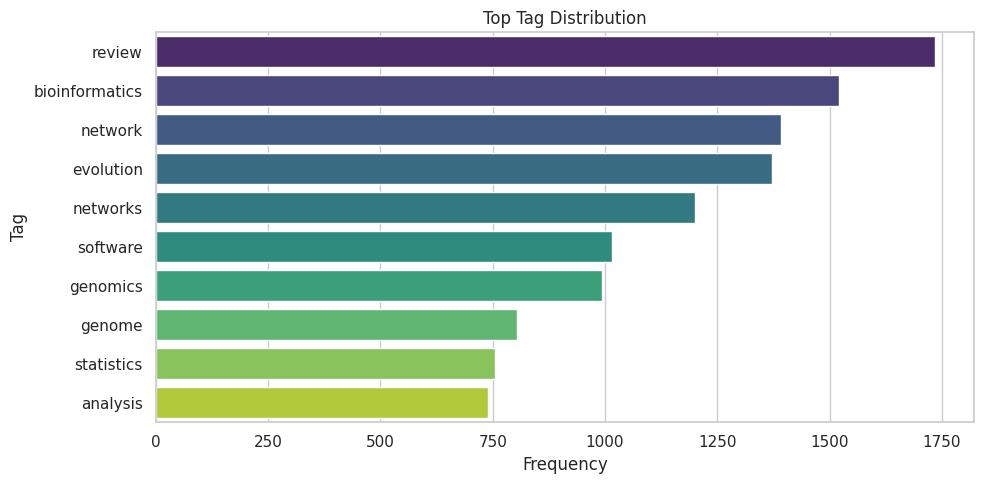

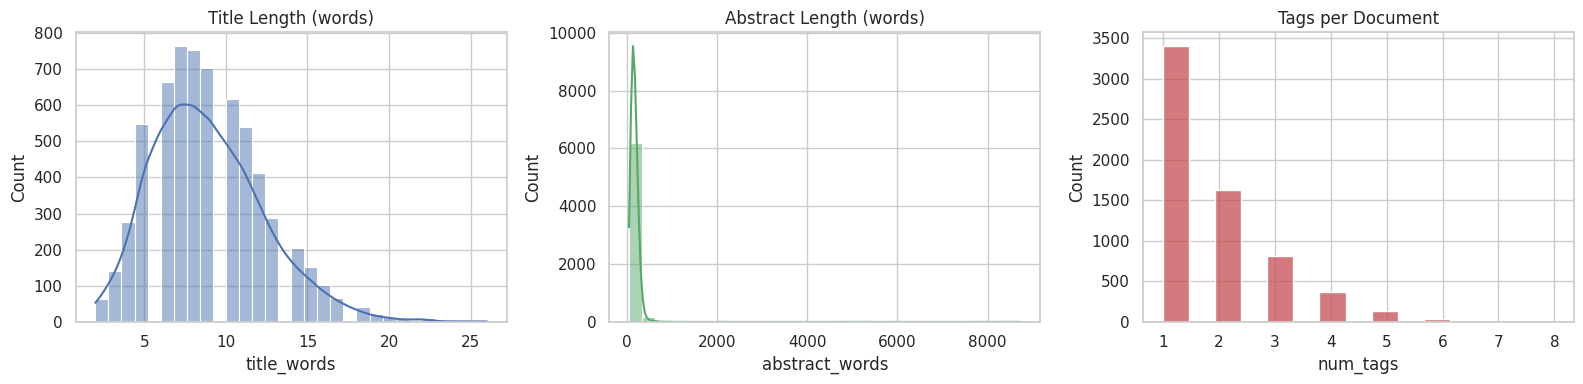

In [6]:
# Cellule 5 - Fonction visualisation EDA
def visualize_eda(df: pd.DataFrame):
    fig1 = plot_tag_distribution(df, top_n=TOP_K_TAGS)
    fig2 = plot_text_length_distributions(df)
    plt.show()
    return fig1, fig2


_ = visualize_eda(df)

In [7]:
# Cellule 6 - Préparation train/test
def make_splits(df: pd.DataFrame):
    return prepare_train_test(
        df,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )


X_flat_train, X_flat_test, X_hier_train, X_hier_test, y_train, y_test, mlb = make_splits(df)
print("Train:", len(X_flat_train), "Test:", len(X_flat_test), "Labels:", len(mlb.classes_))
print("Hier train:", len(X_hier_train), "Hier test:", len(X_hier_test), "Labels:", len(mlb.classes_))


Train: 5757 Test: 640 Labels: 10
Hier train: 5757 Hier test: 640 Labels: 10


In [8]:
def train_models(X_flat_train, X_flat_test, y_train, y_test, n_topics: int, glove_path: str, threshold: float, topk: int):
    return run_all_models(
        X_train=X_flat_train,
        X_test=X_flat_test,
        y_train=y_train,
        y_test=y_test,
        n_topics=n_topics,
        glove_path=glove_path,
        threshold=threshold,
        topk=topk,
    )

def train_models_hierarchical(X_hier_train, X_hier_test, y_train, y_test, n_topics: int, glove_path: str, threshold: float, topk: int):
    return run_all_models_hierarchical(
        X_hier_train=X_hier_train,
        X_hier_test=X_hier_test,
        y_train=y_train,
        y_test=y_test,
        n_topics=n_topics,
        glove_path=glove_path,
        threshold=threshold,
        topk=topk,
    )


In [9]:
# Mode top-k (aligné article) — k calculé automatiquement depuis y_train
metrics_df, predictions = train_models(
    X_flat_train, X_flat_test, y_train, y_test,
    n_topics=TOP_K_TAGS,
    glove_path=str(GLOVE_PATH),
    threshold=0.5,
    topk=None, # Pour etre coherent avec Wang et al. article 400.pdf
)
metrics_df

Training NB model...
Training SVM model (BOW, calibrated)...
Training LDA model...
Training LDA model (TF-IDF)...
Training Doc2Vec model...
Training Bi-GRU+Attention model...
Building embedding matrix...
Found in embedding matrix 13047 vectors out of 15000
Building Bi-GRU+Attention model...
Epoch 1/30
 3/81 [>.............................] - ETA: 3s - loss: 0.6831  

I0000 00:00:1776385772.122449   44898 service.cc:146] XLA service 0x7fa6400dd1d0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776385772.122467   44898 service.cc:154]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1776385772.138575   44903 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


81/81 [==============================] - 7s 57ms/step - loss: 0.4890 - val_loss: 0.4661
Epoch 2/30
81/81 [==============================] - 5s 57ms/step - loss: 0.4588 - val_loss: 0.4561
Epoch 3/30
81/81 [==============================] - 5s 56ms/step - loss: 0.4385 - val_loss: 0.4226
Epoch 4/30
81/81 [==============================] - 5s 59ms/step - loss: 0.3978 - val_loss: 0.3859
Epoch 5/30
81/81 [==============================] - 5s 56ms/step - loss: 0.3651 - val_loss: 0.3603
Epoch 6/30
81/81 [==============================] - 5s 58ms/step - loss: 0.3473 - val_loss: 0.3509
Epoch 7/30
81/81 [==============================] - 5s 55ms/step - loss: 0.3367 - val_loss: 0.3367
Epoch 8/30
81/81 [==============================] - 4s 54ms/step - loss: 0.3291 - val_loss: 0.3396
Epoch 9/30
81/81 [==============================] - 4s 53ms/step - loss: 0.3223 - val_loss: 0.3238
Epoch 10/30
81/81 [==============================] - 5s 58ms/step - loss: 0.3171 - val_loss: 0.3189
Epoch 11/30
81/81 [=

2026-04-17 00:32:07.631734: E tensorflow/core/util/util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


81/81 [==============================] - 10s 64ms/step - loss: 0.5010 - val_loss: 0.4684
Epoch 2/30
81/81 [==============================] - 4s 52ms/step - loss: 0.4664 - val_loss: 0.4682
Epoch 3/30
81/81 [==============================] - 4s 52ms/step - loss: 0.4655 - val_loss: 0.4686
Epoch 4/30
81/81 [==============================] - 4s 52ms/step - loss: 0.4647 - val_loss: 0.4679
Epoch 5/30
81/81 [==============================] - 4s 52ms/step - loss: 0.4644 - val_loss: 0.4678
Epoch 6/30
81/81 [==============================] - 4s 52ms/step - loss: 0.4641 - val_loss: 0.4678
Epoch 7/30
81/81 [==============================] - 4s 52ms/step - loss: 0.4640 - val_loss: 0.4676
Epoch 8/30
81/81 [==============================] - 4s 52ms/step - loss: 0.4632 - val_loss: 0.4675
Epoch 9/30
81/81 [==============================] - 4s 51ms/step - loss: 0.4631 - val_loss: 0.4673
Epoch 10/30
81/81 [==============================] - 4s 52ms/step - loss: 0.4628 - val_loss: 0.4667
Epoch 11/30
81/81 [

,name,micro_recall,micro_precision,micro_f1
0,Bi-GRU+Att,0.531196,0.734132,0.616390
1,SVM,0.490468,0.764865,0.597677
2,NB,0.757366,0.490736,0.595571
3,Paragraph Vector,0.538995,0.639260,0.584861
4,SVM_BOW,0.330156,0.793750,0.466340
5,HAN_BiGRU_Att,0.344887,0.680342,0.457734
6,LDA,0.220971,0.629630,0.327133
7,LDA_TFIDF,0.000867,0.500000,0.001730


In [10]:
# seeds = [42, 123, 456, 789, 1024]
# all_metrics = []
# for seed in seeds:
#     X_flat_train, X_flat_test, X_hier_train, X_hier_test, y_train, y_test, mlb = prepare_train_test(df, random_state=seed)
#     metrics, _ = train_models(
#     X_flat_train, X_flat_test, y_train, y_test,
#     n_topics=TOP_K_TAGS,
#     glove_path=str(GLOVE_PATH),
#     threshold=0.5,
#     topk=None,
#     )
#     metrics["seed"] = seed
#     all_metrics.append(metrics)
# df_all = pd.concat(all_metrics)
# summary = df_all.groupby("name").agg(["mean", "std"])
# summary

In [11]:
# Mode top-k (aligné article) — k calculé automatiquement depuis y_train
metrics_df, predictions = train_models_hierarchical(
    X_hier_train, X_hier_test, y_train, y_test,
    n_topics=TOP_K_TAGS,
    glove_path=str(GLOVE_PATH),
    threshold=0.5,
    topk=None, # Pour etre coherent avec Wang et al. article 400.pdf
)
metrics_df

Training NB model...
Training SVM model (BOW, calibrated)...
Training LDA model...
Training LDA model (TF-IDF)...
Training Doc2Vec model...
Training Bi-GRU+Attention model...
Building embedding matrix...
Found in embedding matrix 13063 vectors out of 15000
Building Bi-GRU+Attention model...
Epoch 1/30
81/81 [==============================] - 7s 57ms/step - loss: 0.4930 - val_loss: 0.4636
Epoch 2/30
81/81 [==============================] - 5s 56ms/step - loss: 0.4506 - val_loss: 0.4400
Epoch 3/30
81/81 [==============================] - 5s 57ms/step - loss: 0.4161 - val_loss: 0.4023
Epoch 4/30
81/81 [==============================] - 5s 57ms/step - loss: 0.3802 - val_loss: 0.3677
Epoch 5/30
81/81 [==============================] - 5s 58ms/step - loss: 0.3571 - val_loss: 0.3557
Epoch 6/30
81/81 [==============================] - 4s 54ms/step - loss: 0.3428 - val_loss: 0.3403
Epoch 7/30
81/81 [==============================] - 5s 56ms/step - loss: 0.3332 - val_loss: 0.3344
Epoch 8/30
81/8

,name,micro_recall,micro_precision,micro_f1
0,Bi-GRU+Att,0.545927,0.693833,0.611057
1,NB,0.759965,0.491868,0.597208
2,SVM,0.491334,0.761074,0.597156
3,HAN_BiGRU_Att,0.499133,0.726356,0.591680
4,Paragraph Vector,0.522530,0.639449,0.575107
5,SVM_BOW,0.331023,0.794179,0.467278
6,LDA,0.235702,0.623853,0.342138
7,LDA_TFIDF,0.006066,0.583333,0.012007


In [12]:
seeds = [42, 123, 456, 789, 1024]
all_metrics = []
for seed in seeds:
    X_flat_train, X_flat_test, X_hier_train, X_hier_test, y_train, y_test, mlb = prepare_train_test(df, random_state=seed)
    metrics, _ = train_models_hierarchical(
    X_hier_train, X_hier_test, y_train, y_test,
    n_topics=TOP_K_TAGS,
    glove_path=str(GLOVE_PATH),
    threshold=0.5,
    topk=None,
    )
    metrics["seed"] = seed
    all_metrics.append(metrics)
df_all = pd.concat(all_metrics)
summary = df_all.groupby("name").agg(["mean", "std"])
summary

Training NB model...
Training SVM model (BOW, calibrated)...
Training LDA model...
Training LDA model (TF-IDF)...
Training Doc2Vec model...
Training Bi-GRU+Attention model...
Building embedding matrix...
Found in embedding matrix 13063 vectors out of 15000
Building Bi-GRU+Attention model...
Epoch 1/30
81/81 [==============================] - 7s 54ms/step - loss: 0.4926 - val_loss: 0.4616
Epoch 2/30
81/81 [==============================] - 4s 55ms/step - loss: 0.4476 - val_loss: 0.4379
Epoch 3/30
81/81 [==============================] - 4s 51ms/step - loss: 0.4145 - val_loss: 0.4020
Epoch 4/30
81/81 [==============================] - 4s 52ms/step - loss: 0.3801 - val_loss: 0.3702
Epoch 5/30
81/81 [==============================] - 5s 56ms/step - loss: 0.3556 - val_loss: 0.3536
Epoch 6/30
81/81 [==============================] - 4s 53ms/step - loss: 0.3436 - val_loss: 0.3476
Epoch 7/30
81/81 [==============================] - 4s 53ms/step - loss: 0.3351 - val_loss: 0.3373
Epoch 8/30
81/8

micro_recall           micro_precision            micro_f1  \
                         mean       std            mean       std      mean   
name                                                                          
Bi-GRU+Att           0.532973  0.009691        0.705074  0.021537  0.606894   
HAN_BiGRU_Att        0.495083  0.034132        0.707021  0.023500  0.581336   
LDA                  0.241550  0.018521        0.643533  0.045688  0.350819   
LDA_TFIDF            0.024282  0.010985        0.615016  0.083021  0.046401   
NB                   0.766861  0.007832        0.501586  0.018236  0.606354   
Paragraph Vector     0.533592  0.012543        0.640857  0.018620  0.582087   
SVM                  0.487997  0.016918        0.758782  0.019590  0.593712   
SVM_BOW              0.321403  0.012891        0.779617  0.017396  0.455063   

                             seed              
                       std   mean         std  
name                                           
Bi-GRU+Att        0.009359  486.8  421.620327  
HAN_BiGRU_Att     0.019768  486.8  421.620327  
LDA               0.022591  486.8  421.620327  
LDA_TFIDF         0.020626  486.8  421.620327  
NB                0.014228  486.8  421.620327  
Paragraph Vector  0.007257  486.8  421.620327  
SVM               0.012030  486.8  421.620327  
SVM_BOW           0.014501  486.8  421.620327

In [13]:
# If you still have 'predictions' dict from the last run:
y_pred_bigru = predictions["Bi-GRU+Att"]

print("=== Bi-GRU+Att Diagnostic ===")
print(f"y_test shape: {y_test.shape}")
print(f"y_test pos rate: {y_test.mean():.4f}")
print(f"y_test avg labels/doc: {y_test.sum(axis=1).mean():.2f}")
print()
print(f"y_pred shape: {y_pred_bigru.shape}")
print(f"y_pred pos rate: {y_pred_bigru.mean():.4f}")
print(f"y_pred avg labels/doc: {y_pred_bigru.sum(axis=1).mean():.2f}")
print()

# If you can access raw probas (before thresholding), inspect them:
# Otherwise, these stats on binary preds are already very telling
print(f"Docs with 0 predicted tags: {(y_pred_bigru.sum(axis=1) == 0).sum()}")
print(f"Docs with >10 predicted tags: {(y_pred_bigru.sum(axis=1) > 10).sum()}")
print(f"Docs with >20 predicted tags: {(y_pred_bigru.sum(axis=1) > 20).sum()}")

=== Bi-GRU+Att Diagnostic ===
y_test shape: (640, 10)
y_test pos rate: 0.1927
y_test avg labels/doc: 1.93

y_pred shape: (640, 10)
y_pred pos rate: 0.1419
y_pred avg labels/doc: 1.42

Docs with 0 predicted tags: 88
Docs with >10 predicted tags: 0
Docs with >20 predicted tags: 0


In [14]:
# Cellule 8 - Sauvegarde facultative des métriques
   
model_params = {
    "NB": {"vectorizer": "CountVectorizer", "max_features": 8000, "ngram_range": [1, 1], "threshold": 0.5},
    "SVM": {"vectorizer": "TfidfVectorizer", "max_features": 8000, "classifier": "CalibratedClassifierCV(LinearSVC", "threshold": 0.0},
    "LDA": {"num_topics": TOP_K_TAGS, "passes": 10, "iterations": 100, "threshold": 0.5},
    "Paragraph Vector": {"vector_size": 200, "window": 3, "epochs": 20, "threshold": 0.5},
    "Bi-GRU+Att": {"max_words": 15000, "max_len": 300, "gru_units": 25, "dense_units": 50, "dropout": 0.2, "epochs": 5, "batch_size": 64, "threshold": 0.5},
}

save_metrics_enriched(
    metrics_df=metrics_df,
    predictions=predictions,
    y_test=y_test,
    top_k_tags=TOP_K_TAGS,
    test_size=0.1,
    random_state=42,
    repeats=1,
    threshold=0.5,
    n_docs=len(df),
    n_unique_tags=len({t for tags in df["tag_list"] for t in tags}),
    avg_tags_per_doc=float(df["tag_list"].apply(len).mean()),
    glove_path=str(GLOVE_PATH),
    model_params=model_params,
    notes="first stable docker run",
)


(PosixPath('data/metrics_results_history_10.csv'), '5d072867df70')

,name,micro_recall,micro_precision,micro_f1
0,Bi-GRU+Att,0.545927,0.693833,0.611057
1,NB,0.759965,0.491868,0.597208
2,SVM,0.491334,0.761074,0.597156
3,HAN_BiGRU_Att,0.499133,0.726356,0.591680
4,Paragraph Vector,0.522530,0.639449,0.575107
5,SVM_BOW,0.331023,0.794179,0.467278
6,LDA,0.235702,0.623853,0.342138
7,LDA_TFIDF,0.006066,0.583333,0.012007


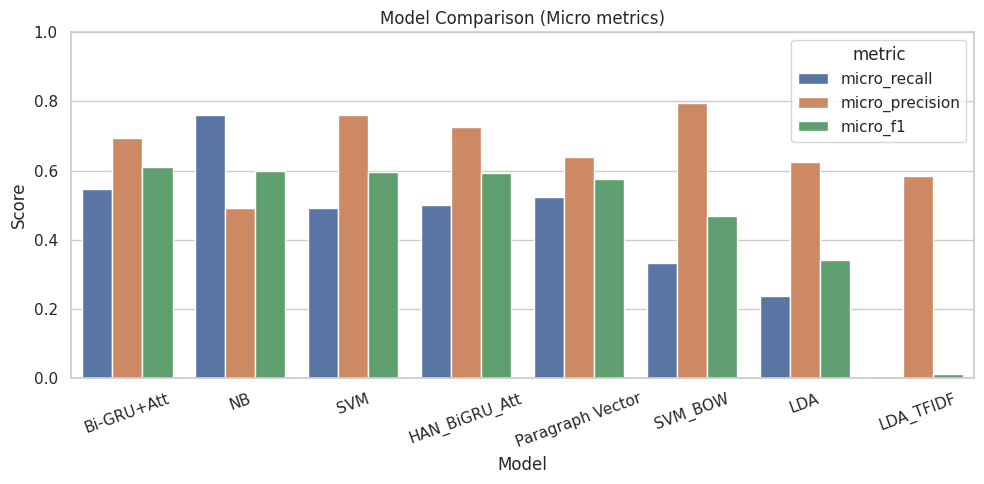

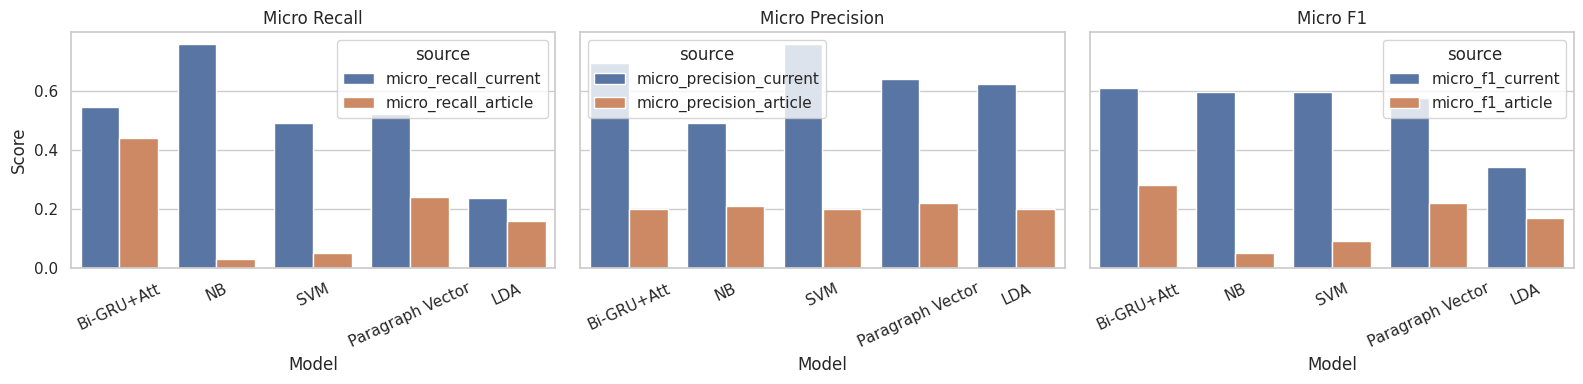

{'best_model': 'Bi-GRU+Att', 'best_micro_f1': 0.6110572259941804}

In [15]:
# Cellule 9 (dernière) - Compilation + visualisations comparatives
def compile_and_compare(metrics_df: pd.DataFrame):
    display(metrics_df.sort_values("micro_f1", ascending=False).reset_index(drop=True))

    fig_models = plot_model_metrics(metrics_df)
    fig_article = plot_article_vs_current(metrics_df)
    plt.show()

    return {
        "best_model": metrics_df.sort_values("micro_f1", ascending=False).iloc[0]["name"],
        "best_micro_f1": float(metrics_df["micro_f1"].max()),
    }


summary = compile_and_compare(metrics_df)
summary